In [1]:
import pandas as pd
import numpy as np

In [3]:
# Load the data
df = pd.read_csv('ecommerce_customer_churn_dataset.csv')

In [4]:
print("Dataset Loaded Successfully!")
df.head()

Dataset Loaded Successfully!


,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


In [5]:
# 1. Handling Outliers & Errors
# Fix Age: Replace ages > 100 with the median age
df.loc[df['Age'] > 100, 'Age'] = df['Age'].median()

In [6]:
# Fix Total Purchases: Replace negative values with 0
df.loc[df['Total_Purchases'] < 0, 'Total_Purchases'] = 0

In [9]:
# 2. Handling Missing Values (Imputation)
# We fill missing numerical values with the 'Median' because it is not affected by outliers.
numerical_cols = df.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

In [10]:
# We fill missing categorical values (like text) with the 'Mode' (most frequent value).
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [11]:
# 3. Verification
print("Cleaning Complete!")
print("-" * 30)
print(f"Total Missing Values remaining: {df.isnull().sum().sum()}")
print("\nQuick Statistical Check (Age and Total Purchases):")
print(df[['Age', 'Total_Purchases']].describe())

Cleaning Complete!
------------------------------
Total Missing Values remaining: 0

Quick Statistical Check (Age and Total Purchases):
               Age  Total_Purchases
count  50000.00000     50000.000000
mean      37.75700        13.116560
std       11.18107         7.005246
min        5.00000         0.000000
25%       30.00000         8.000000
50%       38.00000        12.000000
75%       45.00000        17.000000
max       75.00000       128.700000


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
# Set the style for the plots
sns.set(style="whitegrid")

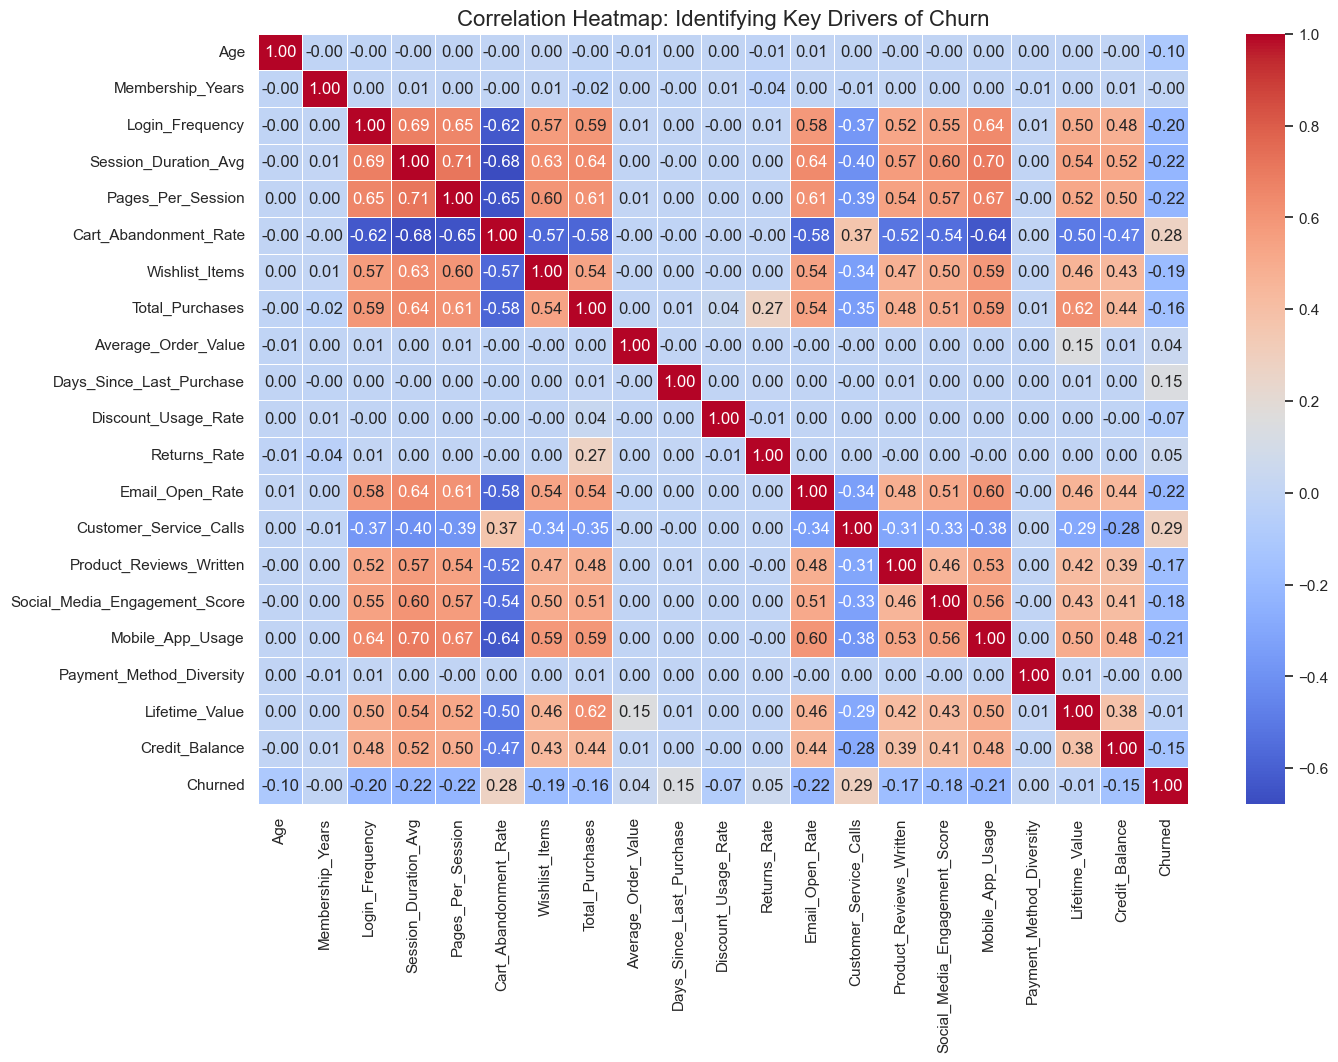

In [14]:
# 1. Correlation Heatmap
# This shows the relationship between all numerical variables and 'Churned'
plt.figure(figsize=(15, 10))
correlation_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap: Identifying Key Drivers of Churn', fontsize=16)
plt.show()

C:\Users\nihad\AppData\Local\Temp\ipykernel_17848\2752704349.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churned', data=df, palette='viridis')


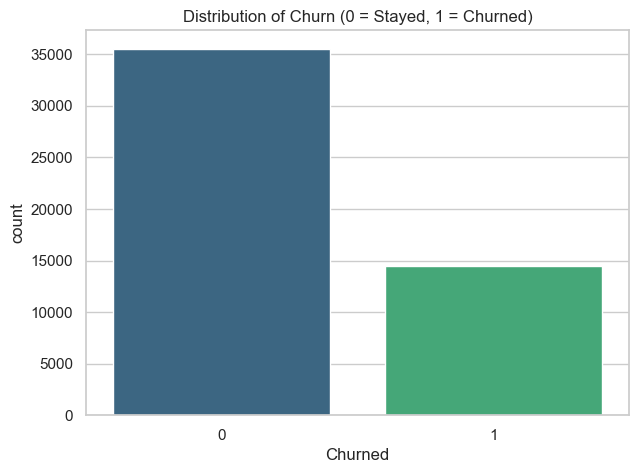

In [15]:
# 2. Target Variable Distribution
plt.figure(figsize=(7, 5))
sns.countplot(x='Churned', data=df, palette='viridis')
plt.title('Distribution of Churn (0 = Stayed, 1 = Churned)')
plt.show()

C:\Users\nihad\AppData\Local\Temp\ipykernel_17848\439038061.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churned', y='Customer_Service_Calls', data=df, palette='magma')


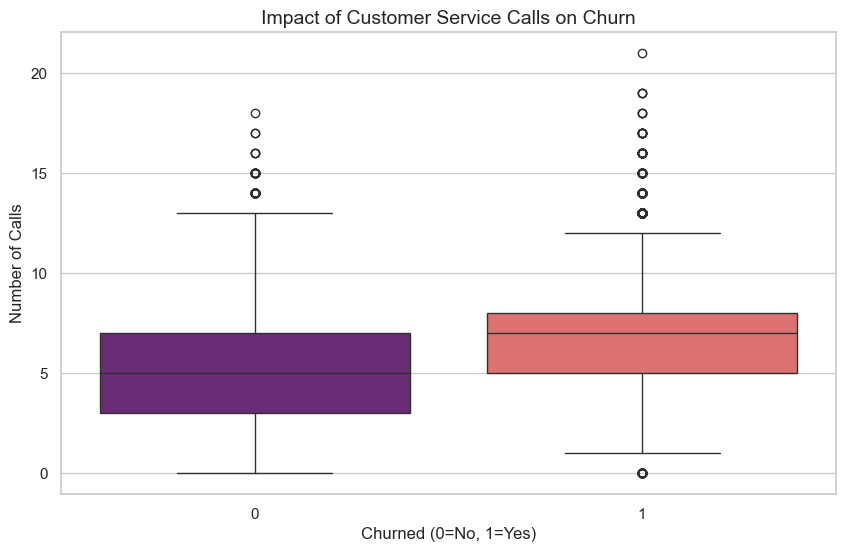

In [16]:
# 3. Behavioral Analysis: Customer Service Calls vs Churn
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churned', y='Customer_Service_Calls', data=df, palette='magma')
plt.title('Impact of Customer Service Calls on Churn', fontsize=14)
plt.xlabel('Churned (0=No, 1=Yes)')
plt.ylabel('Number of Calls')
plt.show()

C:\Users\nihad\AppData\Local\Temp\ipykernel_17848\1546979284.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Churned', y='Cart_Abandonment_Rate', data=df, palette='coolwarm')


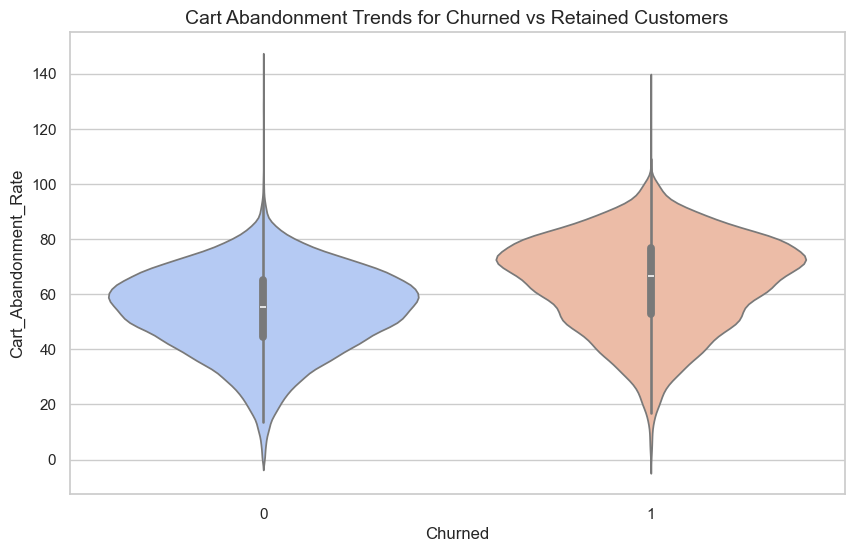

In [17]:
# 4. Friction Analysis: Cart Abandonment Rate vs Churn
plt.figure(figsize=(10, 6))
sns.violinplot(x='Churned', y='Cart_Abandonment_Rate', data=df, palette='coolwarm')
plt.title('Cart Abandonment Trends for Churned vs Retained Customers', fontsize=14)
plt.show()

C:\Users\nihad\AppData\Local\Temp\ipykernel_17848\994855979.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['Churned'] == 0]['Lifetime_Value'], label='Stayed', shade=True)
C:\Users\nihad\AppData\Local\Temp\ipykernel_17848\994855979.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['Churned'] == 1]['Lifetime_Value'], label='Churned', shade=True)


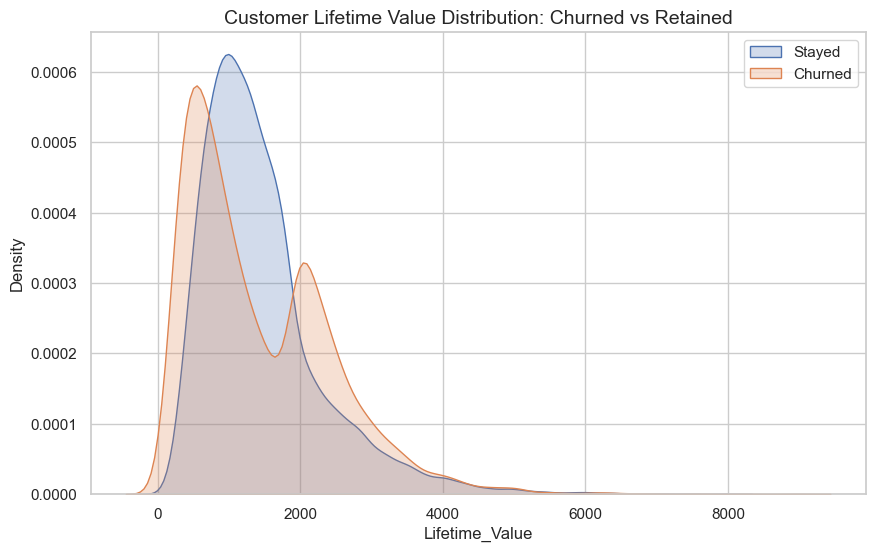

In [18]:
# 5. Financial Analysis: Lifetime Value (LTV) Distribution
plt.figure(figsize=(10, 6))
sns.kdeplot(df[df['Churned'] == 0]['Lifetime_Value'], label='Stayed', shade=True)
sns.kdeplot(df[df['Churned'] == 1]['Lifetime_Value'], label='Churned', shade=True)
plt.title('Customer Lifetime Value Distribution: Churned vs Retained', fontsize=14)
plt.legend()
plt.show()

Boxplot (Calls): This usually shows that customers who call support more often are more frustrated and thus more likely to leave.

Violinplot (Abandonment): This visualizes the "friction" in the shopping process. A higher density of churned users at the top of the graph proves abandonment is a "High-Risk Indicator".

KDE Plot (LTV): This helps you identify if you are losing your "High Value" customers (the ones with high LTV) or just casual users. This addresses the "Business Community" impact mentioned in your synopsis.

Step 4: Feature Engineering & Selection.

Categorical Encoding: We will use a technique called One-Hot Encoding to convert columns like Gender, Country, and Signup_Quarter into binary (0 and 1) columns.


Feature Scaling: Columns like Lifetime_Value have large numbers (e.g., 2000), while Membership_Years has small numbers (e.g., 3). If we don't scale them, the model might think Lifetime_Value is 1000 times more important just because the number is bigger. We will use StandardScaler to normalize them.

Feature Selection: We will drop columns that don't help the model, like City (if it has too many unique values) or unique IDs, to keep the model efficient.

In [19]:
from sklearn.preprocessing import StandardScaler

In [20]:
# 1. Feature Selection: Dropping 'City' as it might be too specific for a general model
# and can lead to 'overfitting'. 
df_ml = df.drop(['City'], axis=1)

In [21]:
# 2. Categorical Encoding (One-Hot Encoding)
# This creates new columns for each category (e.g., Country_France, Country_UK, etc.)
categorical_cols = ['Gender', 'Country', 'Signup_Quarter']
df_ml = pd.get_dummies(df_ml, columns=categorical_cols, drop_first=True)

In [22]:
# 3. Feature Scaling
# We scale all numerical columns except the target 'Churned'
scaler = StandardScaler()
features_to_scale = df_ml.drop('Churned', axis=1).columns

In [23]:
# Apply scaling
df_ml[features_to_scale] = scaler.fit_transform(df_ml[features_to_scale])

In [24]:
# 4. Final Verification
print("Feature Engineering Complete!")
print(f"Original columns: {df.shape[1]}")
print(f"New columns after Encoding: {df_ml.shape[1]}")
print("\nScaled Data Preview (First 5 rows):")
display(df_ml.head())

Feature Engineering Complete!
Original columns: 25
New columns after Encoding: 33

Scaled Data Preview (First 5 rows):


,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,...,Country_Canada,Country_France,Country_Germany,Country_India,Country_Japan,Country_UK,Country_USA,Signup_Quarter_Q2,Signup_Quarter_Q3,Signup_Quarter_Q4
0,0.468922,-0.040799,0.304118,-0.019266,-0.741695,-0.397970,-0.416436,-0.587645,-0.161746,0.164025,...,-0.370078,3.385189,-0.330549,-0.274857,-0.231725,-0.421204,-0.730062,-0.577997,-0.579136,-0.576365
1,-0.157142,-0.672148,0.432150,1.438275,0.431898,-1.190229,-1.069915,0.911246,-0.231633,1.445821,...,-0.370078,-0.295404,-0.330549,-0.274857,-0.231725,2.374148,-0.730062,-0.577997,-0.579136,1.735012
2,0.647798,-0.040799,-0.208008,-0.266953,-1.942582,0.848763,-1.069915,-0.573370,0.241517,-0.632767,...,2.702131,-0.295404,-0.330549,-0.274857,-0.231725,-0.421204,-0.730062,-0.577997,-0.579136,1.735012
3,1.631613,-0.186495,-0.208008,1.028639,1.660078,-0.944567,1.544001,0.268864,0.137911,0.614385,...,-0.370078,-0.295404,-0.330549,-0.274857,-0.231725,-0.421204,1.369747,-0.577997,-0.579136,-0.576365
4,-0.246580,0.056331,2.224591,2.267073,-0.086666,-2.332555,1.544001,2.767017,0.103565,1.515107,...,-0.370078,-0.295404,-0.330549,3.638255,-0.231725,-0.421204,-0.730062,-0.577997,-0.579136,1.735012


Step 5: Machine Learning Modeling.

Train-Test Split: We will take your 50,000 records and split them. We'll use 80% (40,000 records) to train the model and keep 20% (10,000 records) hidden to test it. This proves to your examiners that the model actually "learned" and didn't just "memorize" the data.

Logistic Regression (Baseline): A simple algorithm to give us a starting accuracy score.

Random Forest (Advanced): A more complex model that uses an "ensemble" of many decision trees. This is usually much more accurate for behavioral data like yours.


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [26]:
# 1. Splitting the data into Features (X) and Target (y)
X = df_ml.drop('Churned', axis=1)
y = df_ml['Churned']

In [27]:
# 2. Train-Test Split (80% Training, 20% Testing)
# random_state=42 ensures the results are the same every time you run it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
print(f"Training set size: {X_train.shape[0]} customers")
print(f"Testing set size: {X_test.shape[0]} customers")
print("-" * 30)

Training set size: 40000 customers
Testing set size: 10000 customers
------------------------------


In [29]:
# 3. Training Model 1: Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

In [30]:
# 4. Training Model 2: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

In [31]:
# 5. Comparing Accuracy
lr_acc = accuracy_score(y_test, lr_preds)
rf_acc = accuracy_score(y_test, rf_preds)

In [32]:
print(f"Logistic Regression Accuracy: {lr_acc:.2%}")
print(f"Random Forest Accuracy: {rf_acc:.2%}")

Logistic Regression Accuracy: 77.74%
Random Forest Accuracy: 91.53%


Step 6: Evaluation & Interpretation

In [33]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [34]:
# 1. Detailed Classification Report
# This gives us Precision, Recall, and F1-Score
print("Random Forest Detailed Performance:")
print(classification_report(y_test, rf_preds))

Random Forest Detailed Performance:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      7130
           1       0.92      0.77      0.84      2870

    accuracy                           0.92     10000
   macro avg       0.92      0.87      0.89     10000
weighted avg       0.92      0.92      0.91     10000



<Figure size 800x600 with 0 Axes>

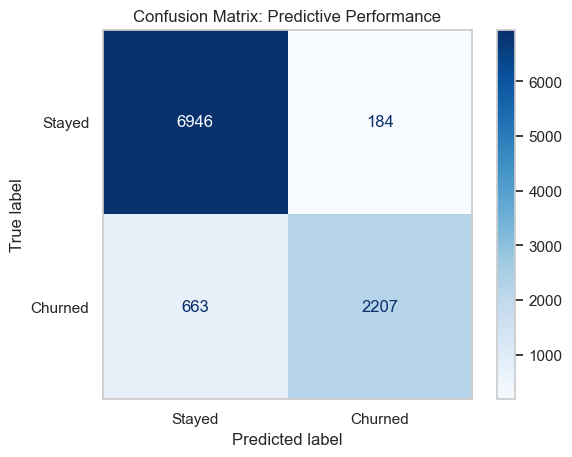

In [35]:
# 2. Confusion Matrix Visualization
# This shows exactly how many 'Stayed' and 'Churned' customers were predicted correctly
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, rf_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Churned'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix: Predictive Performance')
plt.grid(False) # Clean up the grid lines
plt.show()

In [36]:
# 3. Feature Importance: What drives churn?
# This shows which factors the model found most important
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

C:\Users\nihad\AppData\Local\Temp\ipykernel_17848\2643188741.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


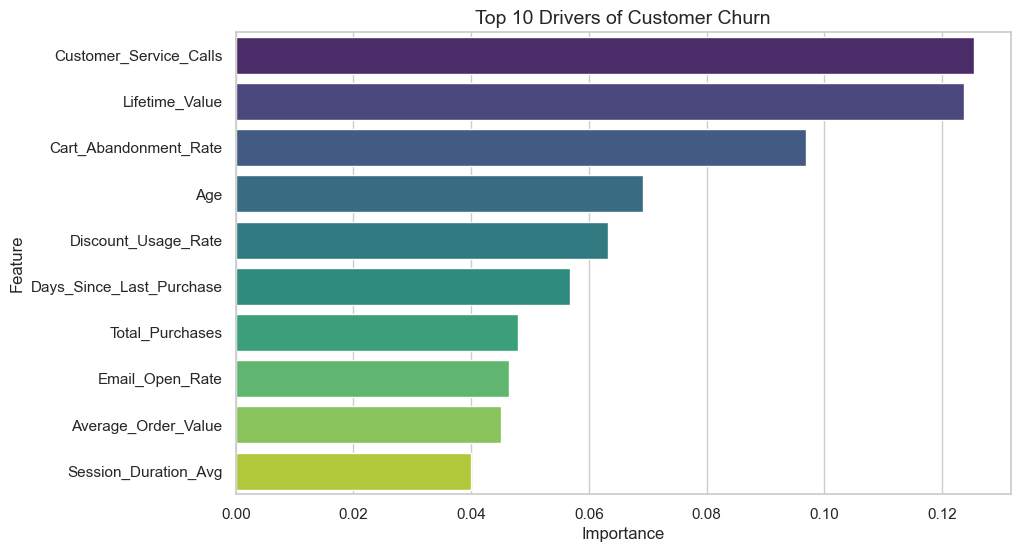

In [37]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Top 10 Drivers of Customer Churn', fontsize=14)
plt.show()

Step 7: The Python Code for your Web App

In [38]:
import joblib

In [39]:
# Save the model and the scaler to files
joblib.dump(rf_model, 'churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
# Save the feature names to ensure the app uses the same order
joblib.dump(X.columns.tolist(), 'feature_columns.pkl')

print("Model and Scaler saved successfully!")

Model and Scaler saved successfully!


In [40]:
import sys
print(sys.executable)

C:\Users\nihad\anaconda3\python.exe


In [41]:
import sys
import os
print(os.path.dirname(sys.executable))

C:\Users\nihad\anaconda3
